Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Uploading Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving mushroom_dataset.csv to mushroom_dataset.csv


In [ ]:
import os
os.listdir()

['.config', 'mushroom_dataset.csv', 'sample_data']

In [ ]:
df = pd.read_csv("mushroom_dataset.csv", sep=';')

In [ ]:
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


In [ ]:
df.shape

(61069, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type             3177 non-null   object 
 15  veil-color         

Missing Value Handling

In [ ]:
df = df.drop(['stem-root', 'veil-type', 'veil-color', 'spore-print-color'], axis=1)
# (We used this to drop these columns)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-surface          22945 non-null  object 
 12  stem-color            61069 non-null  object 
 13  has-ring              61069 non-null  object 
 14  ring-type             58598 non-null  object 
 15  habitat            

In [ ]:
categorical_cols = ['cap-surface', 'gill-attachment',
                    'gill-spacing', 'stem-surface', 'ring-type']

for col in categorical_cols:
    df[col]=df[col].fillna(df[col].mode()[0])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           61069 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       61069 non-null  object 
 7   gill-spacing          61069 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-surface          61069 non-null  object 
 12  stem-color            61069 non-null  object 
 13  has-ring              61069 non-null  object 
 14  ring-type             61069 non-null  object 
 15  habitat            

In [ ]:
df.isnull().sum()

,0
class,0
cap-diameter,0
cap-shape,0
cap-surface,0
cap-color,0
does-bruise-or-bleed,0
gill-attachment,0
gill-spacing,0
gill-color,0
stem-height,0


Encoding

In [ ]:
df_encoded = df.copy()

In [ ]:
df_encoded['class'] = df_encoded['class'].map({'e':0, 'p':1})

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])

In [ ]:
pd.DataFrame({               #we can check how did we use label-encoding here, like for each column, how did the values got encoded into numbers
    'Original': df['cap-surface'],
    'Encoded': df_encoded['cap-surface']
}).head(10)

,Original,Encoded
0,g,2
1,g,2
2,g,2
3,h,3
4,h,3
5,g,2
6,h,3
7,h,3
8,g,2
9,g,2


Correlation Matrix

In [ ]:
corr_matrix = df_encoded.corr()

corr_matrix

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-surface,stem-color,has-ring,ring-type,habitat,season
class,1.000000,-0.181139,-0.106309,-0.026163,0.026411,-0.019889,-0.095433,-0.049022,-0.060701,-0.121593,-0.197368,-0.153862,-0.094772,0.057559,0.092330,-0.041923,-0.054046
cap-diameter,-0.181139,1.000000,0.103923,0.067225,0.042108,0.179440,0.171773,-0.121393,0.221675,0.422560,0.695330,0.047095,0.008670,0.077024,0.036040,-0.125820,0.037305
cap-shape,-0.106309,0.103923,1.000000,-0.067617,0.016312,0.191804,0.046843,-0.038022,0.115703,0.034473,0.157440,0.093628,0.009061,0.036017,0.146909,-0.124754,-0.027178
cap-surface,-0.026163,0.067225,-0.067617,1.000000,0.113660,-0.095095,0.028598,0.050403,-0.025676,0.072723,0.060477,-0.022864,0.118172,0.097993,-0.050511,0.068960,0.011643
cap-color,0.026411,0.042108,0.016312,0.113660,1.000000,0.010657,0.007889,-0.008889,0.136560,-0.010732,0.000573,-0.005879,0.265525,0.070843,-0.011589,0.031706,0.008443
does-bruise-or-bleed,-0.019889,0.179440,0.191804,-0.095095,0.010657,1.000000,0.046402,-0.147406,0.018613,0.076596,0.183514,0.130660,-0.024913,0.019195,0.000692,-0.102747,-0.051146
gill-attachment,-0.095433,0.171773,0.046843,0.028598,0.007889,0.046402,1.000000,0.066664,0.097762,0.071990,0.229633,-0.054743,0.002933,-0.143827,-0.112069,-0.060099,-0.034507
gill-spacing,-0.049022,-0.121393,-0.038022,0.050403,-0.008889,-0.147406,0.066664,1.000000,-0.315955,-0.220753,0.045916,-0.367643,-0.076356,-0.108506,-0.121583,-0.010124,0.050540
gill-color,-0.060701,0.221675,0.115703,-0.025676,0.136560,0.018613,0.097762,-0.315955,1.000000,0.157327,0.113915,0.065691,0.149863,-0.055640,-0.009038,-0.075768,-0.011360
stem-height,-0.121593,0.422560,0.034473,0.072723,-0.010732,0.076596,0.071990,-0.220753,0.157327,1.000000,0.436117,0.237362,0.138458,0.281049,0.191896,-0.020664,-0.020630


<Axes: >

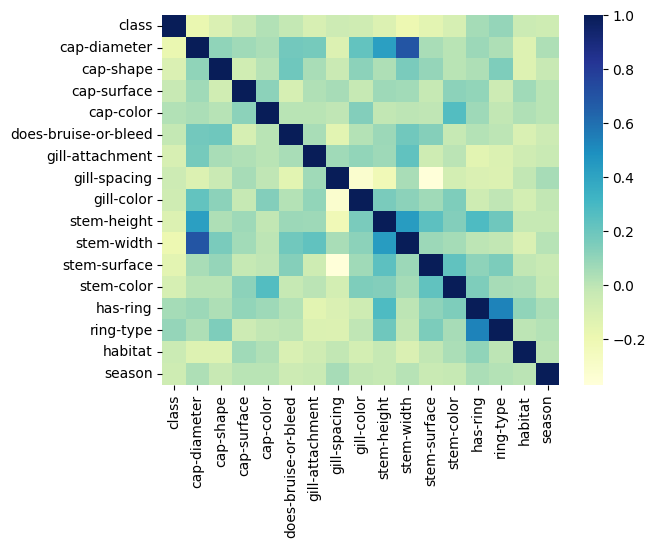

In [ ]:
sns.heatmap(corr_matrix, cmap='YlGnBu')

Imbalance Checking

In [ ]:
df['class'].value_counts()

,count
class,
p,33888
e,27181


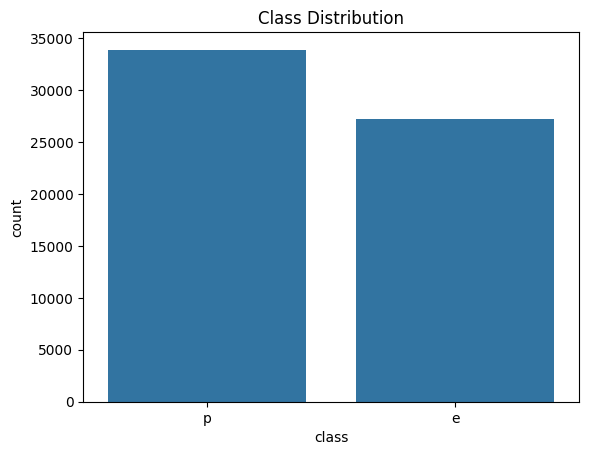

In [ ]:
sns.countplot(x='class', data=df)

plt.title("Class Distribution")

plt.show()

Descriptive Analysis

In [ ]:
# Selecting numerical features
numerical_data = df.select_dtypes(include='number')

# Appending the features of numerical_data to list
numerical_features = numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)


# Selecting categorical features
categorical_data = df.select_dtypes(include='object')

# Appending the features of categorical_data to list
categorical_features = categorical_data.columns.tolist()

print(f'\nThere are {len(categorical_features)} categorical features:', '\n')
print(categorical_features)

There are 3 numerical features: 

['cap-diameter', 'stem-height', 'stem-width']

There are 14 categorical features: 

['class', 'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-surface', 'stem-color', 'has-ring', 'ring-type', 'habitat', 'season']


In [ ]:
numerical_data.describe().T #the behavior and spread of numerical features.

,count,mean,std,min,25%,50%,75%,max
cap-diameter,61069.0,6.733854,5.264845,0.38,3.48,5.86,8.54,62.34
stem-height,61069.0,6.581538,3.370017,0.00,4.64,5.95,7.74,33.92
stem-width,61069.0,12.149410,10.035955,0.00,5.21,10.19,16.57,103.91


In [ ]:
categorical_data.describe().T #the distribution and dominance of categorical values.

,count,unique,top,freq
class,61069,2,p,33888
cap-shape,61069,7,x,26934
cap-surface,61069,11,t,22316
cap-color,61069,12,n,24218
does-bruise-or-bleed,61069,2,f,50479
gill-attachment,61069,7,a,22582
gill-spacing,61069,3,c,49773
gill-color,61069,12,w,18521
stem-surface,61069,8,s,44149
stem-color,61069,13,w,22926


In [ ]:
numerical_data.var()

,0
cap-diameter,27.718592
stem-height,11.357014
stem-width,100.720394


In [ ]:
numerical_data.skew()

,0
cap-diameter,3.822844
stem-height,2.020904
stem-width,2.164957


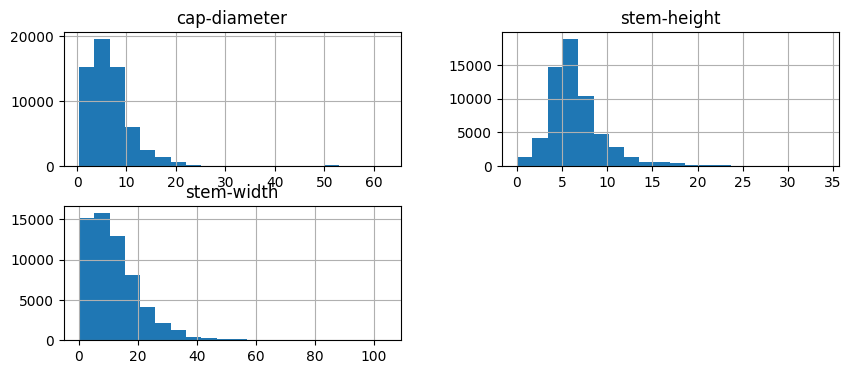

In [ ]:
numerical_data.hist(figsize=(10,4), bins=20)

plt.show()

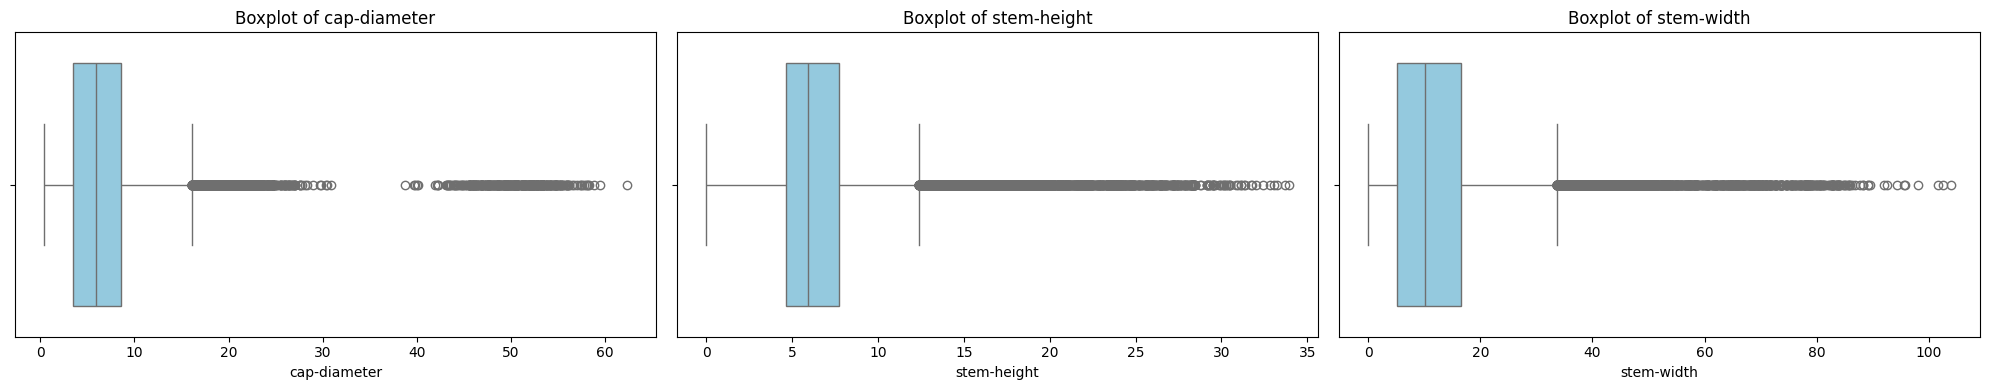

In [ ]:
# Setting up
plt.figure(figsize=(20, 4))

# Plotting boxplots for numerical features
for i, col in enumerate(numerical_features, 1):
    plt.subplot(1, len(numerical_features), i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [ ]:
numerical_data.nunique()

,0
cap-diameter,2571
stem-height,2226
stem-width,4630


In [ ]:
numerical_data.isnull().sum()

,0
cap-diameter,0
stem-height,0
stem-width,0


In [ ]:
# unique values counts for categorical features
unique_counts=categorical_data.nunique()
print(unique_counts)

class                    2
cap-shape                7
cap-surface             11
cap-color               12
does-bruise-or-bleed     2
gill-attachment          7
gill-spacing             3
gill-color              12
stem-surface             8
stem-color              13
has-ring                 2
ring-type                8
habitat                  8
season                   4
dtype: int64


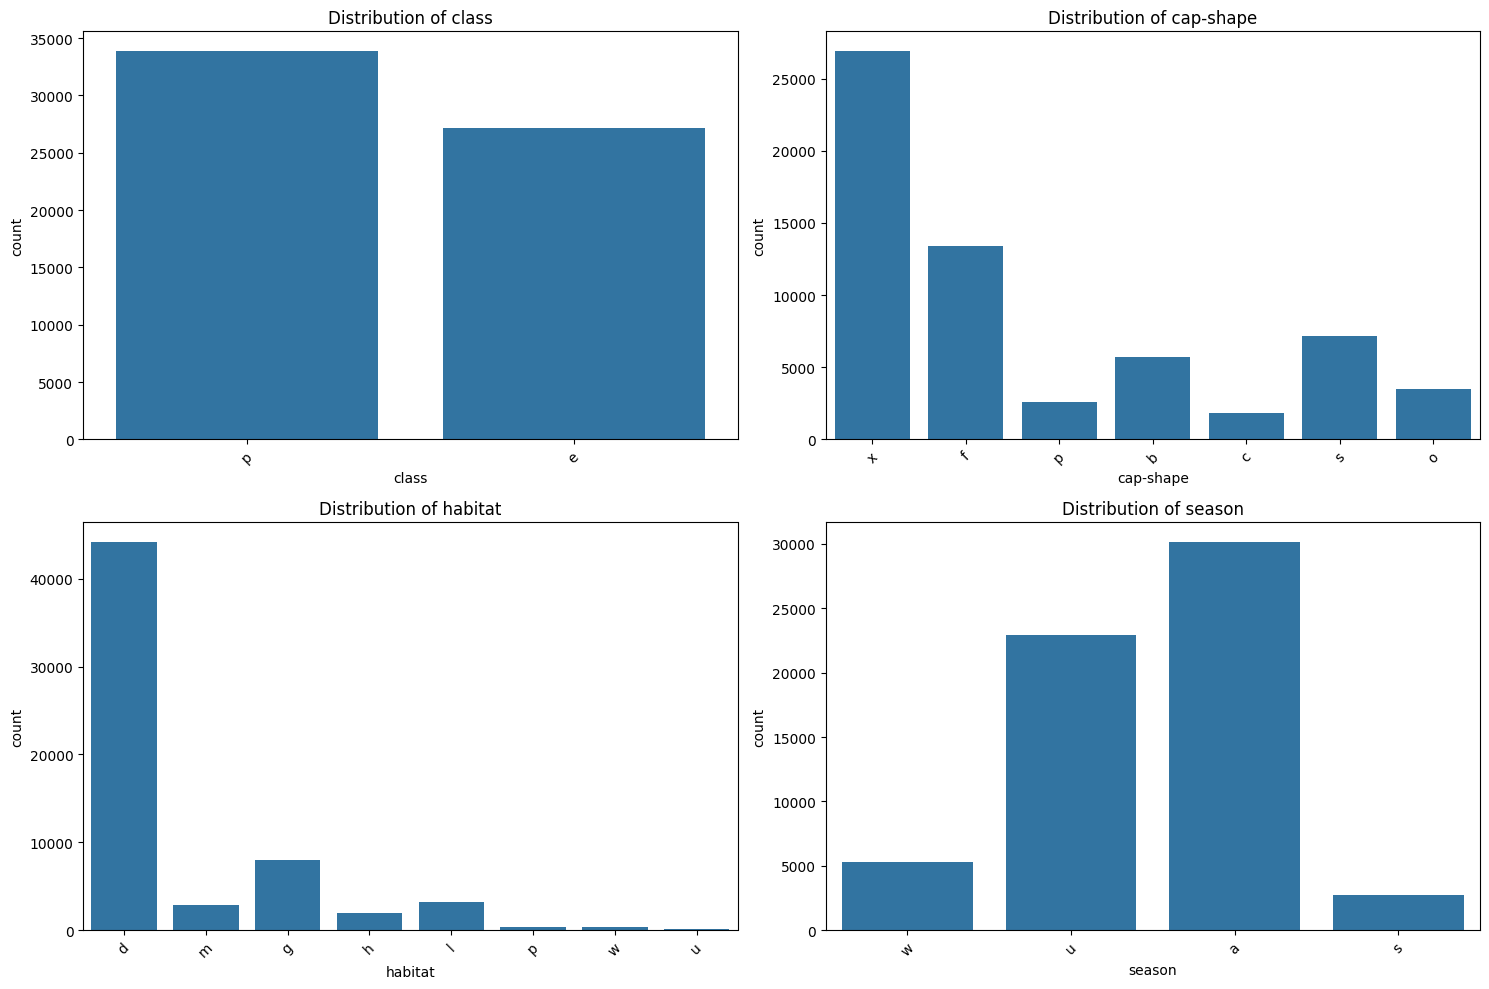

In [ ]:
plt.figure(figsize=(15,10))

for i, col in enumerate(['class', 'cap-shape', 'habitat', 'season'], 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=df[col])
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Relationship Analysis

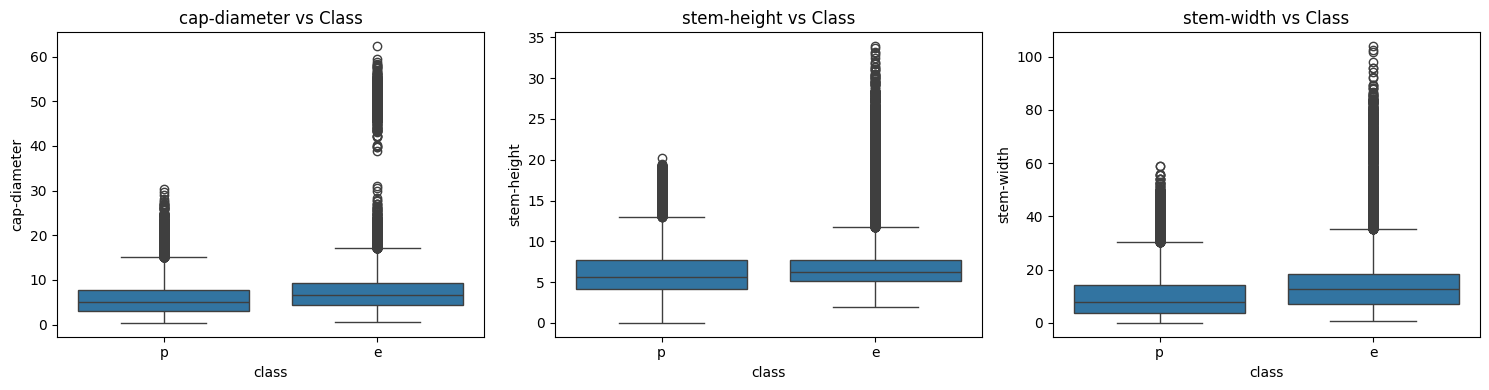

In [ ]:
# Relationship Analysis: Numerical Features vs Target Class

numerical_cols = ['cap-diameter', 'stem-height', 'stem-width']

plt.figure(figsize=(15, 4))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='class', y=col, data=df)
    plt.title(f'{col} vs Class')

plt.tight_layout()
plt.show()

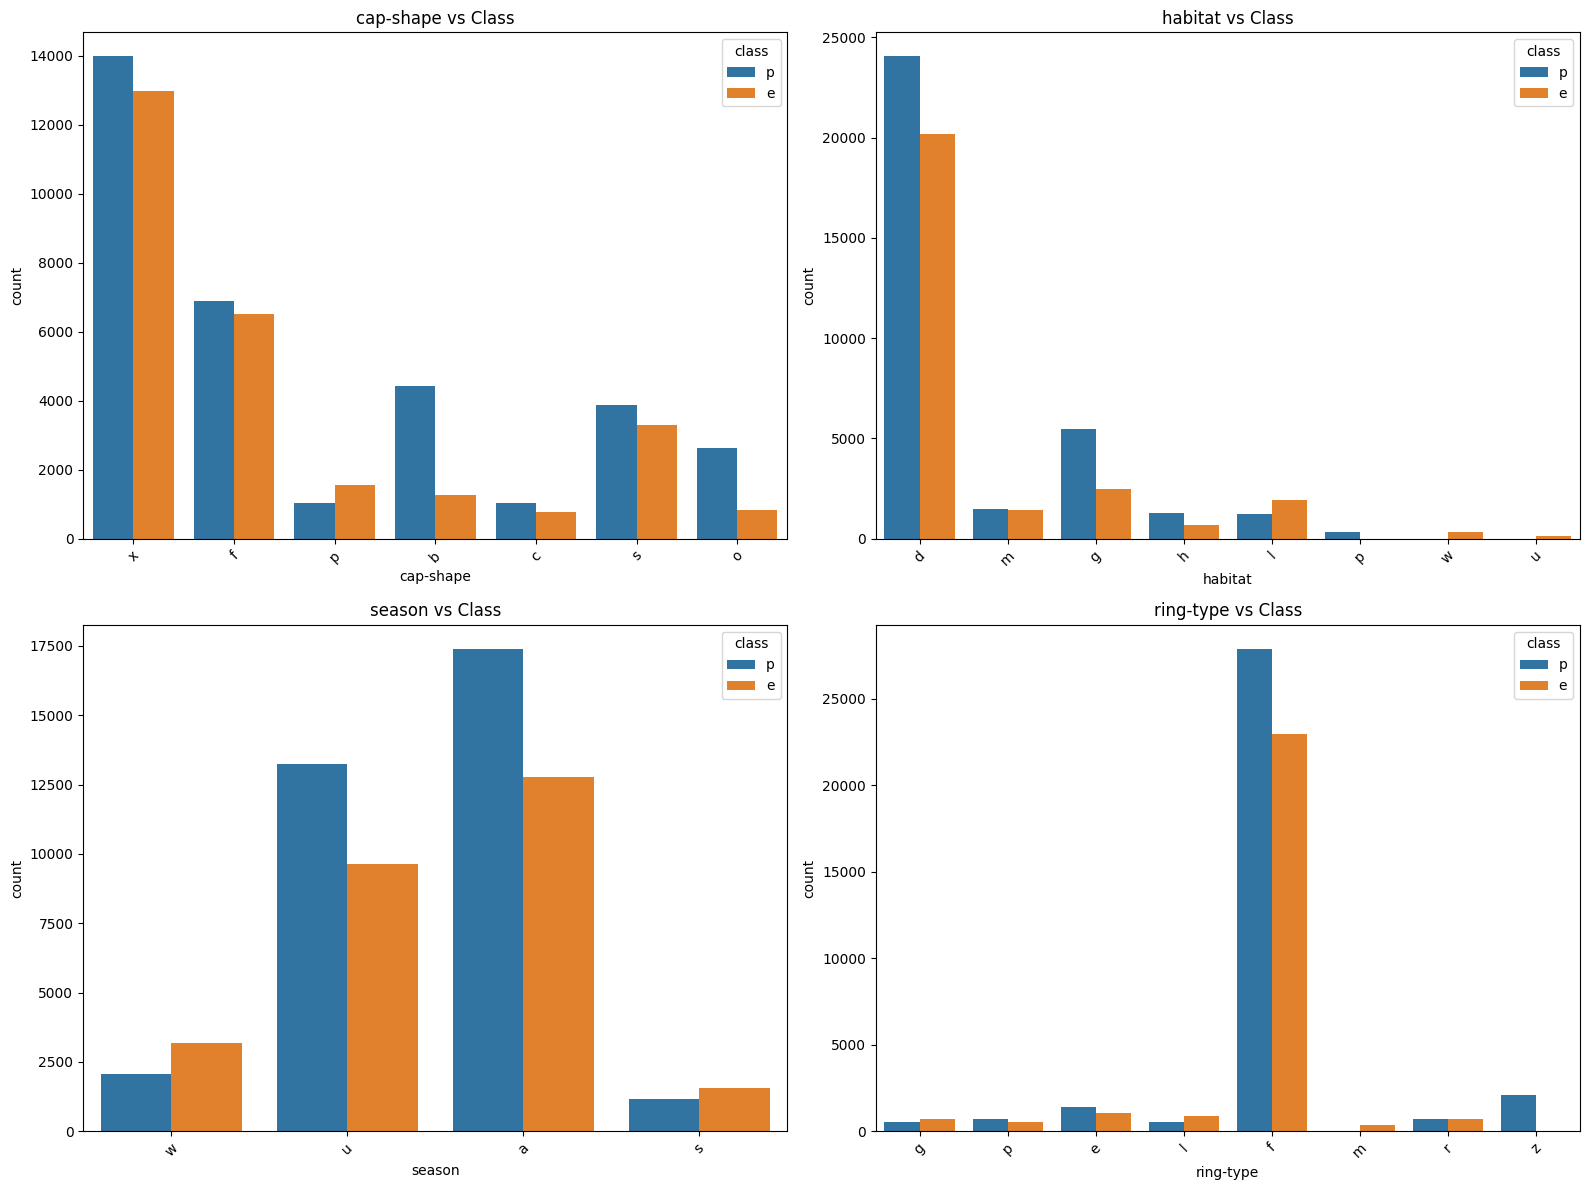

In [ ]:
# Relationship Analysis: Categorical Features vs Target Class

categorical_cols = ['cap-shape', 'habitat', 'season', 'ring-type']

plt.figure(figsize=(16, 12))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=col, hue='class', data=df)
    plt.title(f'{col} vs Class')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# Selecting numerical columns
numerical_cols = ['cap-diameter', 'stem-height', 'stem-width']

# Initializing scaler
scaler = StandardScaler()

# Applying scaling
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

df[numerical_cols].head()

,cap-diameter,stem-height,stem-width
0,1.619462,3.076705,0.492293
1,1.873982,3.385311,0.601900
2,1.393432,3.328931,0.557061
3,1.412426,2.726555,0.381690
4,1.501699,2.952075,0.503254


Dataset Splitting

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# The input features
X = df_encoded.drop('class', axis=1)  #ekhane class column ta drop dicchi

# The target feature
y = df_encoded['class'] #ekhane class column ta rakhtesi

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#xtrain ar xtest hocche jeshob feature amar training er jonno use kora hobe shegular data ar jegula use kora hobena shegular data


# Scaling for better model performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Checking shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (42748, 16)
X_test shape: (18321, 16)
y_train shape: (42748,)
y_test shape: (18321,)


**Model Training & Testing**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

Logistic Regression

In [ ]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=5000) # Create Logistic Regression model
log_reg.fit(X_train, y_train) # Train the model
y_pred_log = log_reg.predict(X_test) # Predict on test data

# Evaluation
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, pos_label=0))
print("Recall:", recall_score(y_test, y_pred_log, pos_label=0))
print("F1 Score:", f1_score(y_test, y_pred_log, pos_label=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log, labels=[0, 1]))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
Accuracy: 0.6454342011898914
Precision: 0.6227909811090798
Recall: 0.50419338924519
F1 Score: 0.5572519083969466

Confusion Matrix:
[[4088 4020]
 [2476 7737]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.50      0.56      8108
           1       0.66      0.76      0.70     10213

    accuracy                           0.65     18321
   macro avg       0.64      0.63      0.63     18321
weighted avg       0.64      0.65      0.64     18321



Decision Tree

In [ ]:
# Decision Tree model
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42) # Create Decision Tree model
dt_model.fit(X_train, y_train) # Train the model
y_pred_dt = dt_model.predict(X_test) # Predict on test data

# Evaluation
print("Decision Tree Results")

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, pos_label=0))
print("Recall:", recall_score(y_test, y_pred_dt, pos_label=0))
print("F1 Score:", f1_score(y_test, y_pred_dt, pos_label=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt, labels=[0,1]))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
Accuracy: 0.9361934392227499
Precision: 0.9034771485056402
Recall: 0.9581894425259003
F1 Score: 0.9300293290237625

Confusion Matrix:
[[7769  339]
 [ 830 9383]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      8108
           1       0.97      0.92      0.94     10213

    accuracy                           0.94     18321
   macro avg       0.93      0.94      0.94     18321
weighted avg       0.94      0.94      0.94     18321



Neural Network

In [ ]:
# Neural Network model
nn_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42) # Create Neural Network model
nn_model.fit(X_train, y_train) # Train the model
y_pred_nn = nn_model.predict(X_test) # Predict on test data

# Evaluation
print("Neural Network Results")

print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print("Precision:", precision_score(y_test, y_pred_nn, pos_label=0))
print("Recall:", recall_score(y_test, y_pred_nn, pos_label=0))
print("F1 Score:", f1_score(y_test, y_pred_nn, pos_label=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nn, labels=[0,1]))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))

Neural Network Results
Accuracy: 0.9996179247857649
Precision: 0.9991373998767714
Recall: 1.0
F1 Score: 0.9995685138383776

Confusion Matrix:
[[ 8108     0]
 [    7 10206]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8108
           1       1.00      1.00      1.00     10213

    accuracy                           1.00     18321
   macro avg       1.00      1.00      1.00     18321
weighted avg       1.00      1.00      1.00     18321



Comparison

In [ ]:
# Creating comparison table
comparison_table = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Neural Network'],

    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_nn)
    ],

    'Precision': [
        precision_score(y_test, y_pred_log, pos_label=0),
        precision_score(y_test, y_pred_dt, pos_label=0),
        precision_score(y_test, y_pred_nn, pos_label=0)
    ],

    'Recall': [
        recall_score(y_test, y_pred_log, pos_label=0),
        recall_score(y_test, y_pred_dt, pos_label=0),
        recall_score(y_test, y_pred_nn, pos_label=0)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_log, pos_label=0),
        f1_score(y_test, y_pred_dt, pos_label=0),
        f1_score(y_test, y_pred_nn, pos_label=0)
    ]
})

comparison_table

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.645434,0.622791,0.504193,0.557252
1,Decision Tree,0.936193,0.903477,0.958189,0.930029
2,Neural Network,0.999618,0.999137,1.000000,0.999569


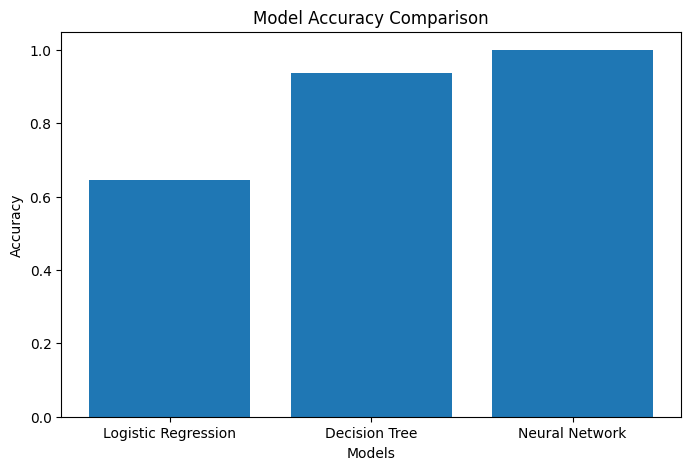

In [ ]:
# Plotting accuracy comparison
plt.figure(figsize=(8,5))

plt.bar(
    comparison_table['Model'],
    comparison_table['Accuracy']
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')

plt.show()

ROC & AUC

In [ ]:
from sklearn.metrics import roc_curve, auc

Logistic Regression AUC Score: 0.7013
Decision Tree AUC Score: 0.9796
Neural Network AUC Score: 1.0000


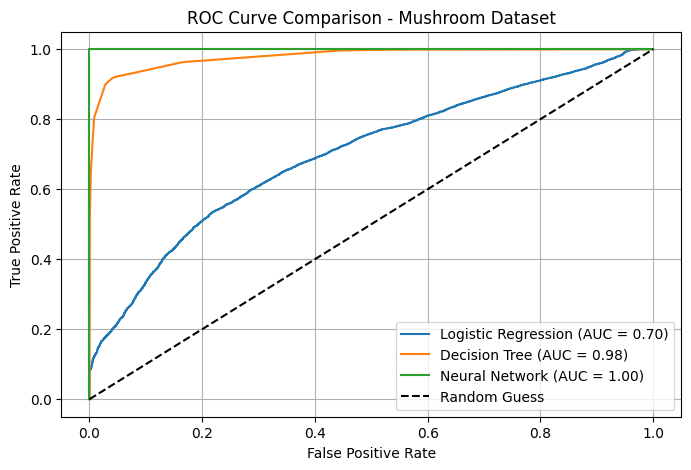

In [ ]:
models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dt_model,
    "Neural Network": nn_model
}

plt.figure(figsize=(8, 5))

for name, model in models.items():

    # Predict probabilities for class 1
    y_probs = model.predict_proba(X_test)[:, 1]

    # Calculating ROC and AUC
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    # Printing AUC score
    print(f"{name} AUC Score: {roc_auc:.4f}")

    # Plotting
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Random guessing line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Plot setup
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Mushroom Dataset")
plt.legend(loc="lower right")
plt.grid()

plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

KMeans Clustering

In [ ]:
from sklearn.cluster import KMeans

# KMeans clustering
cluster = 2

km = KMeans(n_clusters=cluster, random_state=42, n_init=10)

# Fitting and predicting clusters
y_predicted = km.fit_predict(X)

# Adding cluster labels to dataframe
df_cluster = df_encoded.copy()
df_cluster["Group_cluster"] = y_predicted

# Showing cluster centers
print("Cluster Centers:")
print(km.cluster_centers_)

# Showing cluster predictions
print("\nPrediction for the KMeans Clusters")
print(y_predicted)

df_cluster.head(10)

Cluster Centers:
[[ 4.72182182  3.88855449  5.99644732  6.24022448  0.11741944  1.90978005
   0.2357214   7.23986242  5.7173588   7.48476263  4.75663016  8.2953702
   0.23225923  1.43815623  0.68974022  1.04650163]
 [12.00231143  4.4424957   6.24459323  5.89399775  0.32002133  2.63423594
   0.26124311  7.59678853  8.84437044 24.36367186  4.93754814  8.77916691
   0.29122474  1.48100966  0.45085027  1.07110268]]

Prediction for the KMeans Clusters
[1 1 1 ... 0 0 0]


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-surface,stem-color,has-ring,ring-type,habitat,season,Group_cluster
0,1,15.26,6,2,6,0,2,0,10,16.95,17.09,7,11,1,2,0,3,1
1,1,16.60,6,2,6,0,2,0,10,17.99,18.19,7,11,1,2,0,2,1
2,1,14.07,6,2,6,0,2,0,10,17.80,17.74,7,11,1,2,0,3,1
3,1,14.17,2,3,1,0,2,0,10,15.77,15.98,7,11,1,5,0,3,1
4,1,14.64,6,3,6,0,2,0,10,16.53,17.20,7,11,1,5,0,3,1
5,1,15.34,6,2,6,0,2,0,10,17.84,18.79,7,11,1,5,0,2,1
6,1,14.85,2,3,6,0,2,0,10,17.71,16.89,7,11,1,2,0,3,1
7,1,14.86,6,3,1,0,2,0,10,17.03,17.44,7,11,1,5,0,2,1
8,1,12.85,2,2,6,0,2,0,10,17.27,18.69,7,11,1,5,0,0,1
9,1,13.55,2,2,1,0,2,0,10,16.04,16.88,7,11,1,5,0,3,1


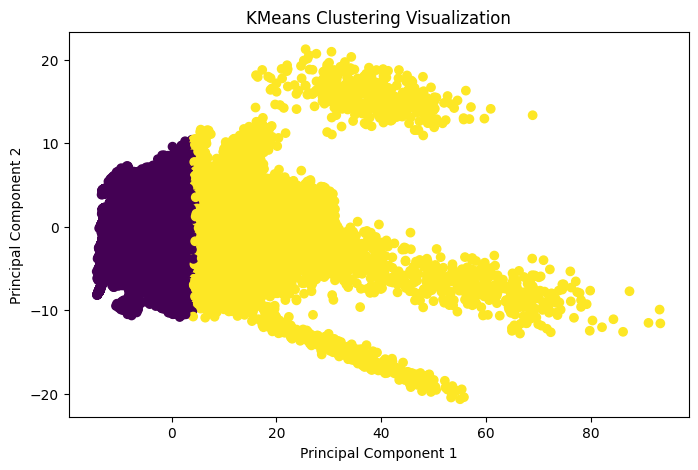

In [ ]:
from sklearn.decomposition import PCA

# Reducing dimensions to 2D
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

# Plotting clusters
plt.figure(figsize=(8,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_predicted,
    cmap='viridis'
)

plt.title("KMeans Clustering Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.savefig("kmeans_pca.png", dpi=300, bbox_inches="tight")

plt.show()